In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
import seaborn as sns

In [3]:
# load dataset 
df = pd.read_csv("mission_launches.csv")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
   Unnamed: 0.1  Unnamed: 0 Organisation  \
0             0           0       SpaceX   
1             1           1         CASC   
2             2           2       SpaceX   
3             3           3    Roscosmos   
4             4           4          ULA   

                                            Location  \
0         LC-39A, Kennedy Space Center, Florida, USA   
1  Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...   
2                      Pad A, Boca Chica, Texas, USA   
3       Site 200/39, Baikonur Cosmodrome, Kazakhstan   
4           SLC-41, Cape Canaveral AFS, Florida, USA   

                         Date                                        Detail  \
0  Fri Aug 07, 2020 05:12 UTC  Falcon 9 Block 5 | Starlink V1 L9 & BlackSky   
1  Thu Aug 06, 2020 04:01 UTC           Long March 2D | Gaofen-9 04 & Q-SAT   
2  Tue Aug 04, 2020 23:57 UTC            Starship Prototype | 150 Meter Hop   
3  Thu Jul 30, 2020 21:25 UTC  Proton-M/Briz-M | Ekspr

In [4]:
#dataset information
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(4324, 9)

Column Names:
Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')

Missing Values:
Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64


In [5]:
#missing value handling
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Handle missing values only if they exist
if df.isnull().sum().sum() > 0:
    df = df.fillna("Unknown")
    print("Missing values handled.")
else:
    print("No missing values found.")

Missing Values:
Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64
Missing values handled.


In [6]:
#remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicates removed")
print(df)

Duplicates removed
      Unnamed: 0.1  Unnamed: 0 Organisation  \
0                0           0       SpaceX   
1                1           1         CASC   
2                2           2       SpaceX   
3                3           3    Roscosmos   
4                4           4          ULA   
...            ...         ...          ...   
4319          4319        4319      US Navy   
4320          4320        4320         AMBA   
4321          4321        4321      US Navy   
4322          4322        4322    RVSN USSR   
4323          4323        4323    RVSN USSR   

                                               Location  \
0            LC-39A, Kennedy Space Center, Florida, USA   
1     Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...   
2                         Pad A, Boca Chica, Texas, USA   
3          Site 200/39, Baikonur Cosmodrome, Kazakhstan   
4              SLC-41, Cape Canaveral AFS, Florida, USA   
...                                                 ...   
431

In [8]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print(df[['Date']].head())

                       Date
0 2020-08-07 05:12:00+00:00
1 2020-08-06 04:01:00+00:00
2 2020-08-04 23:57:00+00:00
3 2020-07-30 21:25:00+00:00
4 2020-07-30 11:50:00+00:00


In [9]:
df['Year'] = df['Date'].dt.year
print(df[['Date', 'Year']].head())

                       Date    Year
0 2020-08-07 05:12:00+00:00  2020.0
1 2020-08-06 04:01:00+00:00  2020.0
2 2020-08-04 23:57:00+00:00  2020.0
3 2020-07-30 21:25:00+00:00  2020.0
4 2020-07-30 11:50:00+00:00  2020.0


In [16]:
#launches per year
launches_per_year = df.groupby('Year').size(
    
)

print(launches_per_year.head())

Year
1957.0     3
1958.0    22
1959.0    20
1960.0    38
1961.0    52
dtype: int64


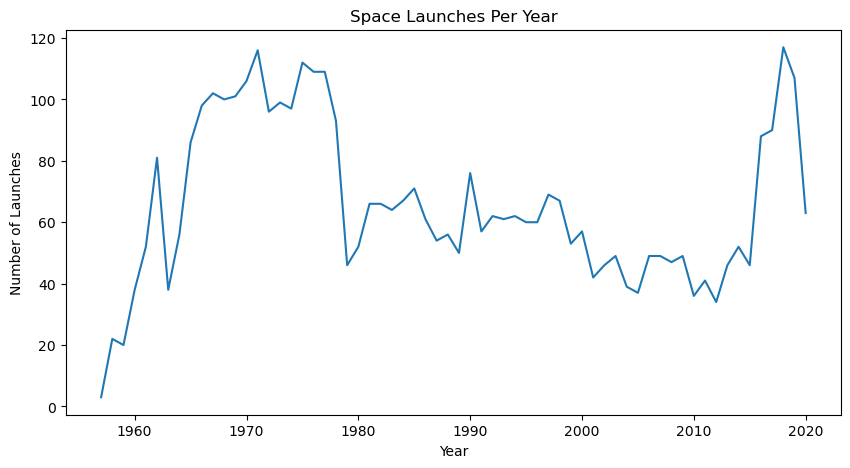

In [17]:
%matplotlib inline
plt.figure(figsize=(10,5))

launches_per_year.plot()

plt.title("Space Launches Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Launches")

plt.show()

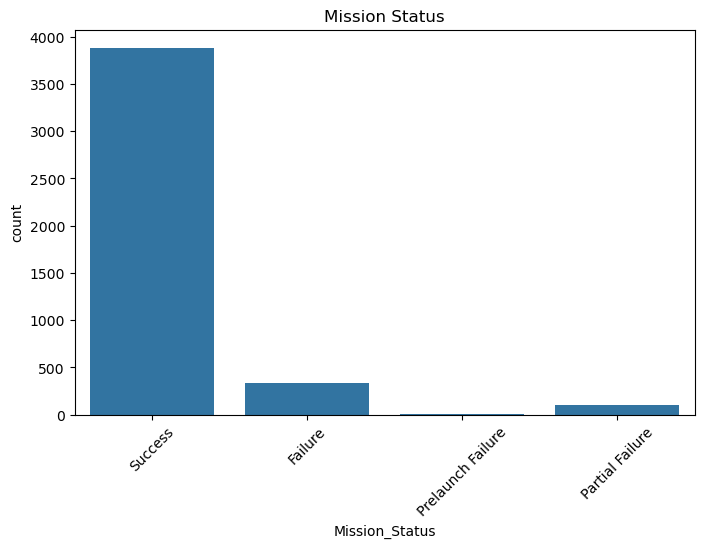

In [21]:
#mission status analysis
plt.figure(figsize=(8,5))

sns.countplot(
    x='Mission_Status',
    data=df
)

plt.title("Mission Status")

plt.xticks(rotation=45)

plt.show()

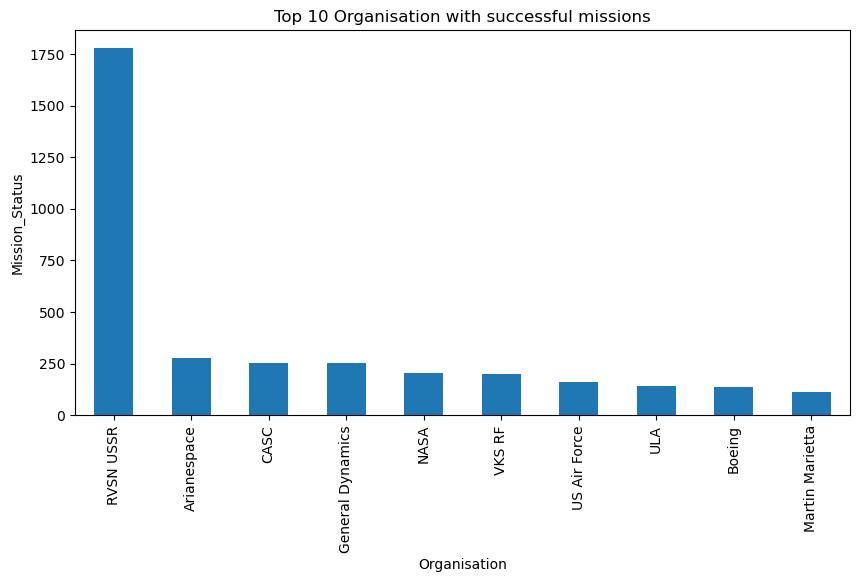

In [22]:
#Top Vehicles types
top_vehicles = df['Organisation'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_vehicles.plot(kind='bar')

plt.title("Top 10 Organisation with successful missions")
plt.xlabel("Organisation")
plt.ylabel("Mission_Status")

plt.show()

In [24]:
df['Launch Site'] = df['Location'].str.split(',').str[-1]

In [27]:
#pivot table
pivot_table = pd.pivot_table(
    df,
    values='Detail',
    index='Year',
    columns='Mission_Status',
    aggfunc='count',
    fill_value=0
)

print(pivot_table.head())

Mission_Status  Failure  Partial Failure  Prelaunch Failure  Success
Year                                                                
1957.0                1                0                  0        2
1958.0               14                2                  0        6
1959.0                9                3                  0        8
1960.0               19                0                  0       19
1961.0               17                3                  0       32


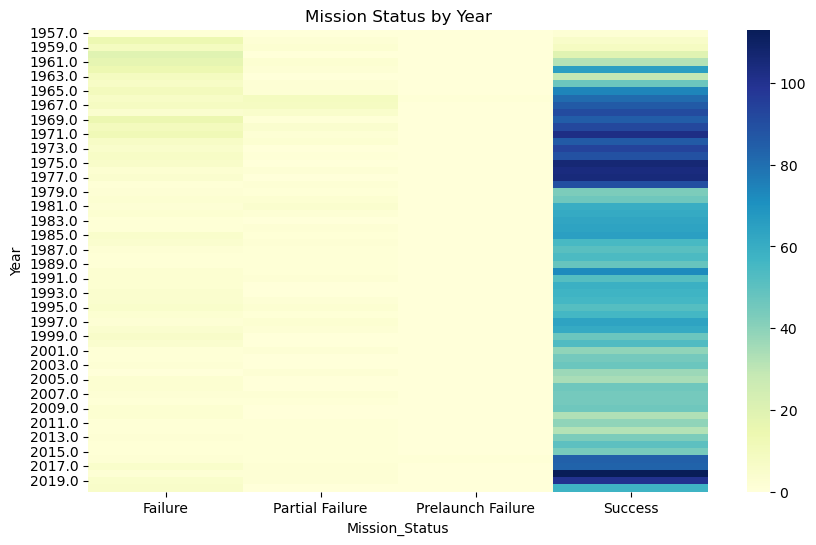

In [28]:
#heatmap from Pivot table
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_table,
    cmap="YlGnBu"
)

plt.title("Mission Status by Year")

plt.show()